In [1]:
import lightgbm as lgb
import numpy as np
import pandas as pd
import optuna

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

In [2]:
RANDOM_STATE = 12345

# Load data

In [3]:
housing_data = fetch_california_housing(as_frame=True)
housing_df = housing_data.frame
feature_cols = list(housing_data.feature_names)
target_cols = list(housing_data.target_names)
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
X = housing_df[feature_cols].values
y = housing_df[target_cols].squeeze()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
X_valid, X_test, y_valid, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=RANDOM_STATE)

print('Train', X_train.shape, y_train.shape)
print('Valid', X_valid.shape, y_valid.shape)
print('Test', X_test.shape, y_test.shape)

Train (16512, 8) (16512,)
Valid (2064, 8) (2064,)
Test (2064, 8) (2064,)


In [5]:
train_data = lgb.Dataset(X_train, label=y_train, feature_name=feature_cols)
valid_data = lgb.Dataset(X_valid, label=y_valid, feature_name=feature_cols)
test_data = lgb.Dataset(X_test, label=y_test, feature_name=feature_cols)

# Get baseline from default parameters

In [6]:
params = {
    'boosting_type': 'gbdt',       # Gradient Boosting Decision Tree
    'objective': 'regression',     # L2 loss (Mean Squared Error); raw model output IS the prediction
    'verbosity': -1,               # < 0: Fatal, = 0: Error (Warning), = 1: Info, > 1: Debug
    'seed': RANDOM_STATE,
    'deterministic': True,
    'force_col_wise': True
}

regressor = lgb.train(
    params=params,
    train_set=train_data,
    valid_sets=[valid_data],
    callbacks=[lgb.early_stopping(stopping_rounds=30, min_delta=0.001, verbose=False)]
)

default_param_mse = regressor.best_score['valid_0']['l2']
print(f'default_param_mse = {default_param_mse:.3f}')

default_param_mse = 0.218


# Optuna

In [7]:
def objective(trial):
    # Define the search space
    n_estimators = trial.suggest_int("n_estimators", 100, 500)
    num_leaves = trial.suggest_int("num_leaves", 31, 127)

    params = {
        'boosting_type': 'gbdt',       # Gradient Boosting Decision Tree
        'objective': 'regression',     # L2 loss (Mean Squared Error); raw model output IS the prediction
        'verbosity': -1,               # < 0: Fatal, = 0: Error (Warning), = 1: Info, > 1: Debug
        'seed': RANDOM_STATE,
        'deterministic': True,
        'force_col_wise': True,
        'n_estimators': n_estimators,  # Number of boosting rounds
        'num_leaves': num_leaves,      # Max tree leaves for base learners
    }

    regressor = lgb.train(
        params=params,
        train_set=train_data,
        valid_sets=[valid_data],
        callbacks=[lgb.early_stopping(stopping_rounds=30, min_delta=0.001, verbose=False)]
    )

    score = regressor.best_score['valid_0']['l2']
    return score

### How TPE (Tree-structured Parzen Estimator) works
1. TPE splits past trials into two groups based on performance — "good" ones and "bad" ones
2. Builds two probability distributions: $l(x)$ (likelihood of good values) and $g(x)$ (likelihood of bad values). It then wants to pick the next hyperparameter value that maximizes the ratio $l(x) / g(x)$ — i.e., a value that's likely under the "good" distribution but unlikely under the "bad" one.
3. Samples `n_ei_candidates` random candidate values from l(x) (the "good" distribution)
4. Scores each candidate using the l(x)/g(x) ratio (this ratio is essentially Expected Improvement)
5. Picks the candidate with the best score as the actual suggestion for that trial

In [8]:
# Hide standard info logs (like "Trial X finished with value...")
optuna.logging.set_verbosity(optuna.logging.WARNING)

sampler = optuna.samplers.TPESampler(
    seed=RANDOM_STATE,
    n_startup_trials=10, # how many trials are pure random search before exploiting. (default=10)
    n_ei_candidates=24,
)
study = optuna.create_study(direction="minimize", sampler=sampler)
study.optimize(objective, n_trials=20)

print("Best Trial:", study.best_trial.number)
print("Best hyperparameters:", study.best_params)
print("Best score:", study.best_value)

Best Trial: 11
Best hyperparameters: {'n_estimators': 389, 'num_leaves': 127}
Best score: 0.1947910470399001


In [9]:
trials_df = study.trials_dataframe()
trials_df = trials_df[['number', 'value', 'params_n_estimators', 'params_num_leaves']]
trials_df

,number,value,params_n_estimators,params_num_leaves
0,0,0.201174,472,61
1,1,0.199735,173,50
2,2,0.198470,327,88
3,3,0.199301,486,94
4,4,0.199301,400,94
5,5,0.196571,399,124
6,6,0.209897,103,41
7,7,0.199301,219,94
8,8,0.197480,424,115
9,9,0.200202,486,101


In [10]:
decreased_mse = float(default_param_mse - trials_df['value'].min())
print(f'Optuna helped reduce MSE by {decreased_mse:.3f} compared to default parameters')

Optuna helped reduce MSE by 0.023 compared to default parameters


# Decomposing Optuna: how does it actually work?
We  open `study.optimize(...)` up. At its core, it just repeats three steps for `n_trials` iterations:
1. **`study.ask()`** — the *sampler* proposes the next hyperparameters, using every trial that has finished so far.
2. Run the **objective** with those parameters to obtain a score.
3. **`study.tell(trial, score)`** — store the result, so the sampler sees one more completed trial next time.
So `study.optimize(objective, n_trials=20)` is literally a manual `ask → objective → tell` loop. All of the intelligence lives in the **sampler** (`TPESampler`), which decides the parameters at `ask()` time.


In [11]:
# study.optimize(objective, n_trials=20) is equivalent to this loop:
manual_sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE, n_startup_trials=10, n_ei_candidates=24)
manual_study = optuna.create_study(direction="minimize", sampler=manual_sampler)

# To focus on the sampler and avoid retraining LightGBM, we copy and replay the (params -> score) pairs from Section 1.
value_lookup = {
    (t.params["n_estimators"], t.params["num_leaves"]): t.value
    for t in study.trials
}

def cached_objective(trial):
    ne = trial.suggest_int("n_estimators", 100, 500)
    nl = trial.suggest_int("num_leaves", 31, 127)
    return value_lookup[(ne, nl)]

# Run 20 trials.
for i in range(20):
    trial = manual_study.ask()        # sampler proposes params from completed trials
    score = cached_objective(trial)   # evaluate or compute score used for minimizaition
    manual_study.tell(trial, score)   # record -> visible to the sampler next iteration

# Verify every trial matches Section 1, parameter-for-parameter.
matches = all(
    (t.params["n_estimators"], t.params["num_leaves"])
    == (s.params["n_estimators"], s.params["num_leaves"])
    for t, s in zip(manual_study.trials, study.trials)
)
print(f"ask/tell reproduced all {len(manual_study.trials)} trials: {matches}")
print(f"best trial: {manual_study.best_trial.number}  "f"params={manual_study.best_params}  value={manual_study.best_value:.6f}")

ask/tell reproduced all 20 trials: True
best trial: 11  params={'n_estimators': 389, 'num_leaves': 127}  value=0.194791


## TPESampler - How does it propose the next hyperparameters?

### Phase 1 — the first `n_startup_trials` are pure random search
`TPESampler` cannot fit any probability model until it has `n_startup_trials` (= 10) finished trials to look at. So trials 0–9 are delegated to a plain `RandomSampler`.  

How does `RandomSampler` draw an integer on a grid `[low, high]` with step `s`? 
It widens the interval by half a step on each side, draws a single uniform number, then snaps it back onto the grid:
$$x = \mathrm{clip}\!\left(\mathrm{round}\!\left(\frac{u - \mathrm{low}}{s}\right)\!\cdot s + \mathrm{low},\ \mathrm{low},\ \mathrm{high}\right),\qquad u \sim \mathrm{Uniform}\!\left(\mathrm{low}-\tfrac{s}{2},\ \mathrm{high}+\tfrac{s}{2}\right)$$

Why does it need to widen the interval by half a step on each side?   
: Rounding a continuous draw from [low, high] biases against the endpoints (half the bin width). Shifting the draw bounds out by step/2 on
each side gives every grid value an equal-width bin, so the sampler is genuinely uniform over the discrete set

The two parameters are drawn one after another from the **same** random number generator (or ramdom state).   
Notice the startup parameters depend only on the seed — **not** on the objective's values — so trials 0–9 are identical on every run.


In [12]:
# Rebuild exactly what RandomSampler did.
random_rng = np.random.RandomState(RANDOM_STATE)   # == RandomSampler(seed=RANDOM_STATE)

def draw_random_int(rng, low, high, step=1):
    lo = low - step / 2          # widen the grid by half a step each side
    hi = high + step / 2
    u = rng.uniform(lo, hi)      # one uniform draw per parameter
    val = int(np.clip(np.round((u - low) / step) * step + low, low, high))
    return u, val

# Trial 0, drawn in the same order as the objective calls suggest_int:
u_ne, ne = draw_random_int(random_rng, 100, 500)
u_nl, nl = draw_random_int(random_rng, 31, 127)
print("trial 0  n_estimators: Uniform(99.5, 500.5) = %.3f -> %d" % (u_ne, ne))
print("trial 0  num_leaves  : Uniform(30.5, 127.5) = %.3f -> %d" % (u_nl, nl))
print("Section 1 trial 0   :", study.trials[0].params)

# Reproduce all 10 startup (random) trials by drawing in the same order.
random_rng = np.random.RandomState(RANDOM_STATE)
random_trials = []
for _ in range(10):
    _, ne = draw_random_int(random_rng, 100, 500)
    _, nl = draw_random_int(random_rng, 31, 127)
    random_trials.append((ne, nl))

startup_matches = all(
    (ne, nl) == (t.params["n_estimators"], t.params["num_leaves"])
    for (ne, nl), t in zip(random_trials, study.trials[:10])
)
print("\nAll 10 random startup trials reproduced from RandomState(seed):", startup_matches)

trial 0  n_estimators: Uniform(99.5, 500.5) = 472.276 -> 472
trial 0  num_leaves  : Uniform(30.5, 127.5) = 61.188 -> 61
Section 1 trial 0   : {'n_estimators': 472, 'num_leaves': 61}

All 10 random startup trials reproduced from RandomState(seed): True


### Phase 2 — Tree-structured Parzen Estimator (trials 10+)
From trial 10 on, `TPESampler` takes over. Because `multivariate=False` (the default), it samples **each parameter independently**. 

For one parameter it does six things:
1. **fetch** all completed trials.
1. **Split** the completed trials by score into **below** (the `gamma(n)` best — the "good" set) and **above** (the rest — the "bad" set), where $\gamma(n) = \lceil 0.1\,n \rceil$. but capped gamma at 25 trials max.
2. **Build $l(x)$** — a Gaussian-mixture (Parzen / KDE) density over the *good* values — and **$g(x)$** over the *bad* values. Each mixture also gets one extra "prior" component spread across the whole range.
3. **Sample `n_ei_candidates` (= 24)** candidate values from $l(x)$.
4. **Score** each candidate by Expected Improvement, $\mathrm{EI}(x) = \log l(x) - \log g(x) = \log\!\left(l(x)/g(x)\right)$ — large where the candidate is likely under the good model *and* unlikely under the bad model.
5. **Return** the candidate with the largest EI.
Below we decompose **trial 10** (the first TPE trial) and recover both of its parameters from scratch.


In [13]:
from optuna.samplers._tpe.sampler import default_gamma, default_weights
from optuna.samplers._tpe.parzen_estimator import _ParzenEstimator, _ParzenEstimatorParameters
from optuna.trial import TrialState

# ---- history visible at trial 10: the 10 completed trials from Section 1 ----
completed = [t for t in study.trials if t.state == TrialState.COMPLETE][:10]
n = len(completed)
n_below = default_gamma(n) 
n_above = n - n_below
print(f"completed trials available: {n}, gamma({n})={n_below} -> keep the {n_below} best as 'below'")

# Step 1: split by score (direction=minimize, so "best" = smallest value)
ranked = sorted(completed, key=lambda t: t.value)
below, above = ranked[:n_below], ranked[n_below:]
print(f"\n{n_below} below (good):", [(t.params["n_estimators"], t.params["num_leaves"], round(t.value, 4)) for t in below])
print(f"{n_above} above (bad) :", [(t.params["n_estimators"], round(t.value, 4)) for t in above])

# Step 2: build l(x) over 'below' and g(x) over 'above'. (one parameter at a time below)
distributions = {
    "n_estimators": optuna.distributions.IntDistribution(low=100, high=500, step=1), # optuna.trial.Trial.suggest_int
    "num_leaves":   optuna.distributions.IntDistribution(low=31, high=127, step=1), # optuna.trial.Trial.suggest_int
}
tpe_params = _ParzenEstimatorParameters(
    prior_weight=1.0, consider_magic_clip=True, consider_endpoints=False,
    weights=default_weights, multivariate=False, categorical_distance_func={},
)

# One shared TPE RNG. It is only ever touched from trial 10 onward, so at this first
# TPE trial it is still exactly RandomState(seed) -- a fact we use to reproduce trial 10.
tpe_rng = np.random.RandomState(RANDOM_STATE)

chosen = {}
for name in ["n_estimators", "num_leaves"]:
    ss = {name: distributions[name]}
    obs_below = {name: np.array([t.params[name] for t in below], dtype=float)}
    obs_above = {name: np.array([t.params[name] for t in above], dtype=float)}
    mpe_below = _ParzenEstimator(obs_below, ss, tpe_params)   # l(x)
    mpe_above = _ParzenEstimator(obs_above, ss, tpe_params)   # g(x)

    if name == "n_estimators":   # show the internals of l(x) once, for intuition
        mix = mpe_below._mixture_distribution
        print(f"\nl(x) for {name}: Gaussian mixture over 'below' values + a uniform prior")
        print("   weights :", np.round(mix.weights, 4))
        print("   means   :", mix.distributions[0].mu)
        print("   sigmas  :", mix.distributions[0].sigma)

    # Steps 3 & 4: draw 24 candidates from l(x), score by EI = log l - log g
    candidates = mpe_below.sample(tpe_rng, 24)[name]                 # advances the shared rng
    ei = (mpe_below.log_pdf({name: candidates}) - mpe_above.log_pdf({name: candidates}))

    # Step 5: keep the best candidate
    best_idx = int(np.argmax(ei))
    chosen[name] = int(round(candidates[best_idx]))
    print(f"{name:12s}: 24 candidates ~ l(x), EI-max at idx {best_idx} -> {chosen[name]}")

print("\nReconstructed trial 10:", chosen)
print("Section 1   trial 10:", study.trials[10].params)
print("MATCH:", chosen == {
    "n_estimators": study.trials[10].params["n_estimators"],
    "num_leaves": study.trials[10].params["num_leaves"],
})

completed trials available: 10, gamma(10)=1 -> keep the 1 best as 'below'

1 below (good): [(399, 124, 0.1966)]
9 above (bad) : [(424, 0.1975), (327, 0.1985), (486, 0.1993), (400, 0.1993), (219, 0.1993), (173, 0.1997), (486, 0.2002), (472, 0.2012), (103, 0.2099)]

l(x) for n_estimators: Gaussian mixture over 'below' values + a uniform prior
   weights : [0.5 0.5]
   means   : [399. 300.]
   sigmas  : [299.5 401. ]
n_estimators: 24 candidates ~ l(x), EI-max at idx 17 -> 300
num_leaves  : 24 candidates ~ l(x), EI-max at idx 15 -> 71

Reconstructed trial 10: {'n_estimators': 300, 'num_leaves': 71}
Section 1   trial 10: {'n_estimators': 300, 'num_leaves': 71}
MATCH: True


### Reading the result
- $l(x)$ placed half its weight on the only "good" point seen so far (`n_estimators = 399`) and half on a flat prior at the range centre (`300`). Sampling 24 candidates from $l(x)$ therefore concentrates them **near 399** — the region the one good trial lived in.
- We did **not** return the most likely value under $l(x)$; we returned the one maximising $l(x)/g(x)$. A value that is likely under $l$ *but also likely under $g$* (already well represented among bad trials) is penalised — TPE steers toward regions that are good **and** under-explored.
- As more trials finish, the "good" set grows (`gamma` rises), $l(x)$ sharpens around genuinely good values, and the search keeps narrowing — which is exactly the improvement we saw in Section 1's `trials_df`.
That is the entire Optuna/TPE loop: each trial, refit $l$ and $g$ from the latest results, sample where $l/g$ is largest, evaluate, repeat.


# How many trials should you run? Watch convergence, not a guess
TPE has no fixed 'right' number of trials. The best value improves quickly and then **plateaus**, and where that plateau sits is problem-dependent. Three reference points come straight from TPE's mechanics (see Phase 2 above):
- **Trials 1–10** are pure random search (`n_startup_trials`) — TPE isn't even running yet.
- **~250 trials** is where its 'good' model $l(x)$ reaches its full size of 25 (the `gamma` cap) and stops growing.
- For a **small** search space like ours (2 parameters), the optimum is tiny and gets hit *long before* TPE is fully mature.
So instead of guessing a budget, run slightly more than you think you need, plot `best_value` over trials, and **stop when it flattens**. Below we run 100 trials, draw the convergence curve, and show exactly where a simple *stop after no improvement for 20 trials* rule would have ended the search.
> ⚠️ More trials can also **hurt**: each extra trial is another chance to exploit noise in the validation set (selection overfitting). The larger the search budget, the more you need a separate hold-out set to trust the reported best.
*(This cell trains ~100 LightGBM models, one per trial — about 3 minutes.)*

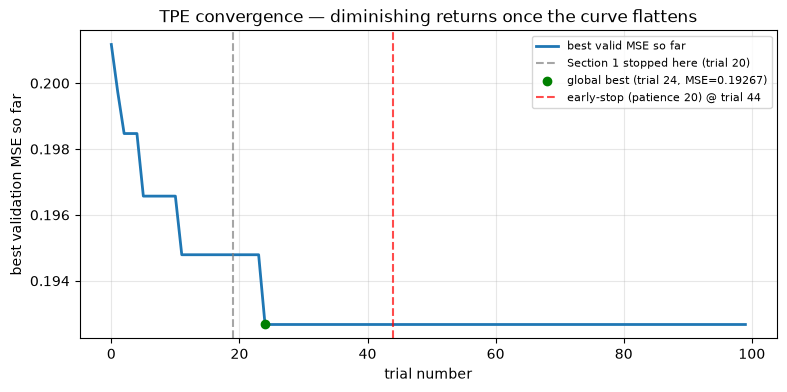

 budget (trials) | best valid MSE
              10 |       0.196571
              20 |       0.194791
              30 |       0.192673
              50 |       0.192673
             100 |       0.192673

Global best:        trial 24  (MSE=0.192673)
Section 1 (20 trl):  MSE=0.194791
Early-stop (patience 20) would have stopped at trial 44 (MSE=0.192673) — ~55% of the compute saved with no loss in MSE.

To stop a live run early, hand the callback to optimize():
  study.optimize(objective, n_trials=1000, callbacks=[StopWhenNoImprovement(20)])


In [14]:
import matplotlib.pyplot as plt

# A reusable callback: stop the study once best_value stalls for `patience` consecutive trials.
class StopWhenNoImprovement:
    """Halt optimization when the best value has not improved for `patience` trials.

    Configured for direction="minimize" (flip the comparison for maximization).
    Calling ``study.stop()`` from inside a callback lets the running trial finish
    and then exits ``optimize()``.
    """

    def __init__(self, patience: int):
        self.patience = patience
        self._best = float("inf")
        self._since = 0

    def __call__(self, study, trial):
        if study.best_value < self._best:
            self._best = study.best_value
            self._since = 0
        else:
            self._since += 1
        if self._since >= self.patience:
            study.stop()


# --- Run a longer study and record the running best value after each trial ---
N_TRIALS = 100                       # ~3 min: one LightGBM fit per trial
best_history = []


def _record(study, trial):
    best_history.append(study.best_value)


conv_sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE, n_startup_trials=10, n_ei_candidates=24)
conv_study = optuna.create_study(direction="minimize", sampler=conv_sampler)
conv_study.optimize(objective, n_trials=N_TRIALS, callbacks=[_record])

# --- Simulate a patience=PATIENCE early-stop on the recorded history (exact: deterministic) ---
PATIENCE = 20
_best, _since, stop_at = float("inf"), 0, None
for i, b in enumerate(best_history):
    if b < _best:
        _best, _since = b, 0
    else:
        _since += 1
    if _since >= PATIENCE:
        stop_at = i
        break

global_best_trial = int(np.argmin(best_history))
global_best = best_history[global_best_trial]

# --- Convergence curve ---
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(best_history, lw=2, label="best valid MSE so far")
ax.axvline(19, color="gray", ls="--", alpha=0.7, label="Section 1 stopped here (trial 20)")
ax.scatter([global_best_trial], [global_best], color="green", zorder=5,
           label=f"global best (trial {global_best_trial}, MSE={global_best:.5f})")
if stop_at is not None:
    ax.axvline(stop_at, color="red", ls="--", alpha=0.7,
               label=f"early-stop (patience {PATIENCE}) @ trial {stop_at}")
ax.set_xlabel("trial number")
ax.set_ylabel("best validation MSE so far")
ax.set_title("TPE convergence — diminishing returns once the curve flattens")
ax.legend(loc="upper right", fontsize=8)
ax.grid(alpha=0.3)
plt.show()

# --- Numbers behind the curve ---
print(f"{'budget (trials)':>16} | {'best valid MSE':>14}")
for n in [10, 20, 30, 50, 100]:
    if n <= len(best_history):
        print(f"{n:>16} | {min(best_history[:n]):>14.6f}")

print(f"\nGlobal best:        trial {global_best_trial}  (MSE={global_best:.6f})")
print(f"Section 1 (20 trl):  MSE={best_history[19]:.6f}")
if stop_at is not None:
    saved = (N_TRIALS - stop_at - 1) * 100 / N_TRIALS
    print(f"Early-stop (patience {PATIENCE}) would have stopped at trial {stop_at} "
          f"(MSE={min(best_history[: stop_at + 1]):.6f}) — "
          f"~{saved:.0f}% of the compute saved with no loss in MSE.")
print("\nTo stop a live run early, hand the callback to optimize():")
print('  study.optimize(objective, n_trials=1000, callbacks=[StopWhenNoImprovement(20)])')

# Optuna with early stoping

In [21]:
sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study = optuna.create_study(direction="minimize", sampler=sampler)
study.optimize(objective, n_trials=50, callbacks=[StopWhenNoImprovement(20)])

In [29]:
n_trails = len(study.trials)
print(f'total trials = {n_trails}')
print(f"best trial: {study.best_trial.number}, params={study.best_params}, value={study.best_value:.6f}")

total trials = 45
best trial: 24, params={'n_estimators': 498, 'num_leaves': 102}, value=0.192673
